<figure>
    <img src="../images/tudelft_logo.png" alt="image" width="250" align="right"/>
</figure>

# 3a: Tidal Environments
  
This week, we will have three notebooks: Notebooks 3a, 3b and 3c. Notebook 3a is about the tidal part of Chapter 4 of the [Coastal Dynamics Open Textbook](https://books.open.tudelft.nl/home/catalog/book/202), which treats the global variation of the main processes that shape the coast (wind, waves, and tides). Notebook 3b is about wave form (wave asymmetry and skewness) and will come in handy when studying both wind waves and tides and related sediment transport, from Chapter 5 onwards. Notebook 3c is about radiation stresses, which are crucial in generating wave-induced currents and water level variations. 

Tidal environments can be classified based on the following two variables: 
- *Magnitude* of the tide, characterised by the tidal range;
- Tidal *character*, determined by the importance of diurnal vs. semi-diurnal components

In this notebook, we will explore both classifications using python code. The notebook consists of *three* parts with a total of *twenty-one* multiple-choice, multiple-selection or numeric questions (1 question in part 1, 12 questions in part 2 and 8 questions in part 3).

## Import the required libraries and questions 

Run the below cells to import all libraries and question files that we use for our analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import pickle
import panel as pn

import coastal_dynamics as cd

pn.extension()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
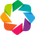

In [2]:
import sys

sys.path.append('../')

from modules import mod_3a

In [3]:
questions = cd.read_questions(Path("../hashed_questions/3a_tidal_environments_hashed.json"))

question_industry = cd.QuestionIndustry(questions)

cd.UseAnswersApp("Q3a").serve()

Column
    [0] Markdown(str)
    [1] Button(name='Help')
    [2] StaticText(value=' ')
    [3] Row
        [0] Button(name='Disregard saved answers')
        [1] Button(button_type='danger', name='Are you sure?', visible=False)
    [4] StaticText(value=' ')
    [5] ParamFunction(function, _pane=Str, defer_load=False)

In [4]:
F_data_fp =  Path("../database/2_wind_waves_tides/02_F_data.pkl")
F_data = pd.read_pickle(F_data_fp)

## Part 1: Classification of tidal environments

### Tidal magnitude and character 

The tidal wave is distorted by local differences in water depth and by the location and shape of land masses and large embayments. This results in a global variation in tidal range controlled by the large-scale coastal configuration. Often used is a tidal classification expressed through mean spring tidal range:

|Category| Mean spring tidal range |
|----------------|:--:|
| Micro-tidal | < 2m | 
| Meso-tidal | 2m - 4m | 
| Macro-tidal | > 4m | 

The tidal character, on the other hand, is defined by the form factor *F* (Eq. 4.1 in the book): <center>*F* = (K1 + O1)/(M2 + S2),</center>

where K1, O1, M2, and S2 are the amplitudes of the corresponding tidal constituents. The tidal character can be used to classify the tide as follows: <br><br>

|Category| Value of F |
|----------------|:--:|
| Semi-diurnal | 0 - 0.25 | 
| Mixed, mainly semi-diurnal | 0.25 - 1.5 | 
| Mixed, mainly diurnal | 1.5 - 3 | 
| Diurnal | > 3 | 

### Global distribution

In the figure below, which consists of Figures 4.10 and 4.12 from the textbook, you can see the world distribution of mean spring tidal range (*left*) and tidal character (*right*). The attribution of the tidal types follows J.L. Davies and Clayton (1980). They classified the world's coastlines using rough coastal data.  

![image](../images/2_wind_waves_tides/02_tidal_env.png)

### Questions for Part 1

- Look into the semi-enclosed seas vs. open coasts and enclosed seas; do you notice anything? Why?
- Compare the left and right figures: do you notice any repetitive patterns? Hint: Look at the tidal range for specific tidal characters.
  
Now run the cell below to get a multiple-selection question that will test your understanding. 

In [5]:
q = [
    "Q3a-classification-trends"
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-1', sizing_mode='stretch_width', value='What can be o...)
        [1] CheckBoxGroup(name='Options', options=['Semi-diurnal and mainly ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

## Part 2: Tidal classification using FES2014 global data

We can also make our own tidal character plot, once again using the [FES2014 Global Tide data](https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes/description-fes2014.html), which provides amplitude and phase information for 34 tidal constituents, distributed on 1/16˚ grids.

- The code cell below plots the tidal characters across the globe obtained from the FES2014 dataset. This code is a bit slow, since it is doing a global contour! Therefore, we have commented out the code and will load the resulting figure for you below this text.
- Compare this figure to the above tidal character plot (Figure 4.12 in the textbook and right panel of the above illustration). What could be the reasons behind the observed differences? 
- Note that the plot also shows four locations that we will consider next.

![image](../images/3_tides_nonlinearity/global_contour.png)

In [6]:
## FES2014 Tidal Characters
# the code is a bit slow, it is doing a global contour!

#mod_3a.tidal_characters(F_data)  # Do not run this code, it is too slow on the hub. Instead we have loaded the resulting plot for you in the above cell

### Tidal curves and tidal character at specific locations

Let's now categorize the tide at the four locations marked in the plot by computing the form factor and look at the tidal curves. 

For each location, we retrieve the tidal signal from the [FES2014 Global Tide data](https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes/description-fes2014.html) as explained in Notebook 2d. We have labelled the locations 1 to 4; later in this notebook you will be asked to match the location labels with the location names. 

Further, the amplitudes of the constituents from the FES2014 dataset, needed to compute the form factor, are shown in the table below. The table also shows the latitude and longitude.

|Tidal amplitudes [cm]| M2 | S2 | K1 | O1 | Longitude | Latitude |
|----------------|:--:|:--:|:--:|:--:|----------------|----------------|
| Scheveningen (Netherlands)  | 75.78 | 17.74 | 8.39  |  11.85 | 4.25 | 52.125 | 
| Galveston (US Gulf of Mexico)  | 13.08| 3.97  |  16.17 | 15.89 | -94.6875 | 29.25 |  
| Jakarta (Indonesia)| 4.58 |  5.18 |  25.75 | 13.46 | 106.8125 | -6.0625 |
| Valparaiso (Chile) | 42.91 | 14.40 | 15.29  |  10.22 | -71.625 | -33 | 

### Questions about Part 2

1. Run the first cell below to get the tidal signals for a time-range that you can specify (select at least a month within the period of 1977-2017). Remember that you can further adjust the figure to your liking; you can **pan** (move the view) and zoom and the two axes are **individually** zoomable as well by hovering over them and using the **wheelzoom** tool. What differences between the curves do you observe? 
2. Now compute the form factor *F* for each location. You can use the empty cell below to write your own code for this calculation.
3. Then run the subsequent cell to get some questions about your results and their interpretation.

In [7]:
# Choose a time window of at least a month to plot (has to be between 1977 - 2017)
start_date = pd.to_datetime("2000-05-01 00:00")
end_date = pd.to_datetime("2000-07-01 00:00")

dir_path = Path("../database/2_wind_waves_tides/")

figure, *_ = mod_3a.FES_tidal_signal(dir_path, start_date, end_date)
display(figure)

:Layout
   .Curve.Total_FES.I   :Curve   [x]   (y)
   .Curve.Total_FES.II  :Curve   [x]   (y)
   .Curve.Total_FES.III :Curve   [x]   (y)
   .Curve.Total_FES.IV  :Curve   [x]   (y)

In [8]:
## Write your code to compute F here.




In [9]:
# Run to get questions about Part 2

q = [
    "Q3a-F-Scheveningen",
    "Q3a-category-Scheveningen",
    "Q3a-F-Galveston",
    "Q3a-category-Galveston",
    "Q3a-F-Jakarta",
    "Q3a-category-Jakarta",
    "Q3a-F-Valparaiso",
    "Q3a-category-Valparaiso",
    "Q3a-label-1",
    "Q3a-label-2",
    "Q3a-label-3",
    "Q3a-label-4",
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-2', sizing_mode='stretch_width', value='What is the f...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-3', sizing_mode='stretch_width', value='What is the t...)
        [1] RadioBoxGroup(name='Options', options=['Semi-diurnal', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [2] Column(width_policy='max')
        [0] StaticText(name='Q-4', sizing_mode='stretch_width', value='What is the f...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [3] Column(width_policy='max')
        [0] StaticText(name='Q-5', sizing_mode='stretch_width', value='What is the t...)
        [1] RadioBoxGroup(name='Options', options=['Semi-diurnal', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [4] Column(width_policy='max')
        [0] StaticText(name='Q-6', sizing_mode='stretch_width', value='What is the f...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [5] Column(width_policy='max')
        [0] StaticText(name='Q-7', sizing_mode='stretch_width', value='What is the t...)
        [1] RadioBoxGroup(name='Options', options=['Semi-diurnal', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [6] Column(width_policy='max')
        [0] StaticText(name='Q-8', sizing_mode='stretch_width', value='What is the f...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [7] Column(width_policy='max')
        [0] StaticText(name='Q-9', sizing_mode='stretch_width', value='What is the t...)
        [1] RadioBoxGroup(name='Options', options=['Semi-diurnal', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [8] Column(width_policy='max')
        [0] StaticText(name='Q-10', sizing_mode='stretch_width', value="Closely look a...)
        [1] RadioBoxGroup(name='Options', options=['Scheveningen', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [9] Column(width_policy='max')
        [0] StaticText(name='Q-11', sizing_mode='stretch_width', value="Closely look a...)
        [1] RadioBoxGroup(name='Options', options=['Scheveningen', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [10] Column(width_policy='max')
        [0] StaticText(name='Q-12', sizing_mode='stretch_width', value="Closely look a...)
        [1] RadioBoxGroup(name='Options', options=['Scheveningen', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [11] Column(width_policy='max')
        [0] StaticText(name='Q-13', sizing_mode='stretch_width', value="Closely look a...)
        [1] RadioBoxGroup(name='Options', options=['Scheveningen', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

## Part 3: Beating of tidal constituents

Now that we've identified the tidal characteristics of each location, we can visualize the tidal constituents that make up the total signal and address various questions. 
We already know from Notebook 2d that M2 and S2 combined give rise to a spring-neap tidal cycle of 14.77 days. We also know that the addition of the diurnal components K1, O1 and P1 leads to daily inequality (and in the extreme to a purely diurnal tide). Here, we are going to consider the beats between some other constituents as well.

We will generate a figure that displays the individual tidal components (upper plot) and their combined tidal signal (lower plot, total signal and sum of selected components) for two of the locations at the same time. The two left plots are for the one location, the two right plot for the other location; in this way you can determine, which of the locations you would like to compare with each other. These are the steps:
- Choose the two locations and data range (within the full period of 1977-2017) in the code cell.
- Execute the block below to generate an interactive figure. 
- Select which tidal constituents to display with tick boxes.
- You can further adjust the time range in the plot using the Bokeh zoom and pan tools.
  
This allows you to experiment with different constituents, observe the resulting signals, and compare the locations. 

#### Important note on the time range
Note that in the below code cell we choose two months as the default time range. You can extend this to a year where necessary, but this will be much slower, so only do this when you need to discern beating periods that exceed the monthly time-scale. You will notice that some of the beatings vary seasonally and that we need a longer time range to discern these. To look at these seasonal variations make sure you comment the appropriate two lines in the below code cell. 

Note further that you can also zoom in using the Bokeh zoom tools. 

In [10]:
# We choose one year to plot, 2000-2001 same as in the previous Notebook
start_date = pd.to_datetime("2000-01-01 00:00")
end_date = pd.to_datetime("2001-01-01 00:00")

# Pre-select a time range of to look at within this year (default: two months):
# Comment out the below two lines if you want to look at the full year
start_date = pd.to_datetime("2000-05-01 00:00")
end_date = pd.to_datetime("2000-07-01 00:00")

# Choose tidal constituents, these will be included in the figure
comps = ['M2', 'S2', 'N2', 'K2',  #semi-diurnal
         'K1', 'O1', 'P1', 'Q1',  #diurnal
         'MF', 'MM', 'SSA',       #long period
         'M4', 'M6', 'S4', 'MN4'] #short period (overtides)

# We start with the M2, S2, K1 and O1 pre-selected

# Select any two out of the four locations, to display the beating of the tidal constituents
# "Scheveningen", "Valparaiso", "Jakarta", "Galveston"
# Examples:
#locs = ["Scheveningen", "Valparaiso"]   # Example statement to select locations Scheveningen and Valparaiso
locs = ["Jakarta", "Galveston"]          # Example statement to select locations Jakarta and Galveston

In [11]:
app = mod_3a.plot_4timeseries_with_interactive_controls(dir_path, locs, comps, start_date, end_date)

app

Column(width_policy='max')
    [0] CheckBoxGroup(inline=True, name='Components', options=['M2', 'S2', 'N2', ...], value=['M2', 'S2', 'K1', 'O1'])
    [1] DateRangeSlider(end=Timestamp('2000-12-31 1..., name='Date range', start=Timestamp('2000-01-01 1..., value=(Timestamp('2000-05-01 00:..., value_end=Timestamp('2000-07-01 0..., value_start=Timestamp('2000-05-01 0...)
    [2] Row(sizing_mode='stretch_width')
        [0] ParamFunction(function, _pane=HoloViews, defer_load=False)

### Open questions about Part 3

In the code above, select the two locations with a (mainly) semi-diurnal character. Also choose the appropriate time ranges (note that you can further adjust the date range where necessary by using the zoom tools of the figure). Investigate the following: 

&emsp;a) Compare the amplitudes of the semi-diurnal components and diurnal components and explain the differences in the total signal based on this. \
&emsp;b) By selecting two components (which ones?), verify the previously computed spring-neap tidal cycle of 14.77 days. \
&emsp;c) What is the approximate beating period of M2 and N2? How would you describe this effect? What is the effect on subsequent spring tides?\
&emsp;d) Select S2 and K2. What is the approximate beating period of these two components? Are there certain times in the year that the resulting tidal amplitudes are largest? \
&emsp;e) Select all semi-diurnal components. Can you still identify the effects investigated above? 

In the code, select the two locations with a (mainly) diurnal character. Investigate the following  (note that you can further adjust the date range where necessary by using the zoom tools of the figure): 

&emsp;f) Compare the amplitudes of the semi-diurnal components and diurnal components and explain the differences in the total signal based on this. \
&emsp;g) What are the three strongest diurnal components at these locations? \
&emsp;h) Could there also be a fortnightly spring-neap tidal cycle from the beating of the most important diurnal component and one of the other diurnal components? Try to determine which other component. \
&emsp;i) Select K1 and P1. What is the approximate beating period of these two components? Are there certain times in the year that the resulting tidal amplitudes are largest? \
&emsp;j) Select all diurnal components. Can you still identify the effects investigated above? 

Now revisit the signal for each location and activate all components, including some short period constituents that we will further explore next week. 

&emsp;k) Analyse the combined signals. What kind of signal do you see for each location? What are the dominant components and beatings at each location? 

When you have finished the above steps, check your understanding by answering the questions below.

### Question block about Part 3: Tidal Beating

Using the knowledge gained from Chapter 3 of the textbook and the interactive figure above, try to answer the questions below. You can use the next cell as a calculator. Give your numeric answer with at least three significant figures. You will need the information in the below table, that was first shown in Notebook 2d.

|Tidal constituents | Name | Equil. <br> Amplitude [m] | Period [h] |
|-|-|-|-|
| **Semi-diurnal** |
| Principal lunar | M2 | 0.24 | 12.4206012 |
| Principal solar | S2 | 0.11 | 12 |
| Lunar elliptical | N2 | 0.046 | 12.65834751 |
| Lunar-solar declinational | K2 | 0.031 | 11.96723606 |
| **Diurnal** |
| Lunar-solar declinational | K1 | 0.14 | 23.93447213 |
| Principal lunar | O1 | 0.10 | 25.81933871 | 
| Principal solar | P1 | 0.047 | 24.06588766 | 
| Lunar elliptical | Q1 | 0.019 | 26.868350 |
| **Long period** |
| Fortnightly | Mf | 0.042 | 327.8599387 |
| Monthly | Mm | 0.022 | 661.3111655 | 
| Semi-annual | Ssa | 0.019 | 4383.076325 | 

In [12]:
# Write your code here to get answers to the questions below. 
# Use the values from the table above and use at least 4 significant figures.




In [13]:
# Run this cell to get the questions
q = [
    "Q3a-semi-diurnal-TC12",
    "Q3a-semi-diurnal-D1",
    "Q3a-diurnal-TC34",
    "Q3a-diurnal-D2",
    "Q3a-semi-diurnal-month12",
    "Q3a-semi-diurnal-TC56",
    "Q3a-diurnal-month34",
    "Q3a-diurnal-TC78"
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-14', sizing_mode='stretch_width', value='In a semi-diurnal environ...)
        [1] CheckBoxGroup(name='Options', options=['M2', 'S2', 'N2', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-15', sizing_mode='stretch_width', value='In a semi-diurnal environ...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [2] Column(width_policy='max')
        [0] StaticText(name='Q-16', sizing_mode='stretch_width', value='In a diurnal environment,...)
        [1] CheckBoxGroup(name='Options', options=['M2', 'S2', 'N2', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [3] Column(width_policy='max')
        [0] StaticText(name='Q-17', sizing_mode='stretch_width', value='In a diurnal environment,...)
        [1] FloatInput(name='Your Answer', width=200)
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [4] Column(width_policy='max')
        [0] StaticText(name='Q-18', sizing_mode='stretch_width', value='Strongest semi-diurnal ti...)
        [1] CheckBoxGroup(name='Options', options=['January', 'February', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [5] Column(width_policy='max')
        [0] StaticText(name='Q-19', sizing_mode='stretch_width', value='Strongest semi-diurnal ti...)
        [1] CheckBoxGroup(name='Options', options=['M2', 'S2', 'N2', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [6] Column(width_policy='max')
        [0] StaticText(name='Q-20', sizing_mode='stretch_width', value='Strongest diurnal tides a...)
        [1] CheckBoxGroup(name='Options', options=['January', 'February', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [7] Column(width_policy='max')
        [0] StaticText(name='Q-21', sizing_mode='stretch_width', value='Strongest diurnal tides a...)
        [1] CheckBoxGroup(name='Options', options=['M2', 'S2', 'N2', ...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

## The end

You have reached the end of this Notebook 3a. You can continue with this week's second notebook, which is Notebook 3b on wave asymmetry and skewness.